In [15]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.data_ingestion import ingest_data

df = ingest_data()

Extracting: multilingual-customer-support-tickets.zip
Loading: aa_dataset-tickets-multi-lang-5-2-50-version.csv

Data ingestion completed.
File: aa_dataset-tickets-multi-lang-5-2-50-version.csv
Shape: (28587, 16)


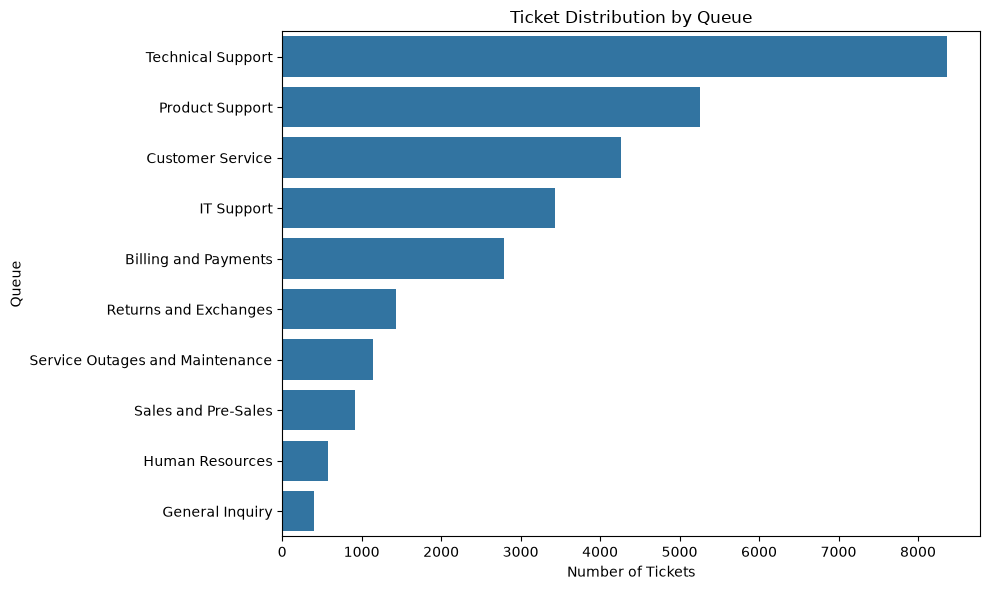

In [16]:
queue_counts = df["queue"].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x = queue_counts.values,
    y = queue_counts.index
)

plt.xlabel("Number of Tickets")
plt.ylabel("Queue")
plt.title("Ticket Distribution by Queue")
plt.tight_layout()
plt.show()

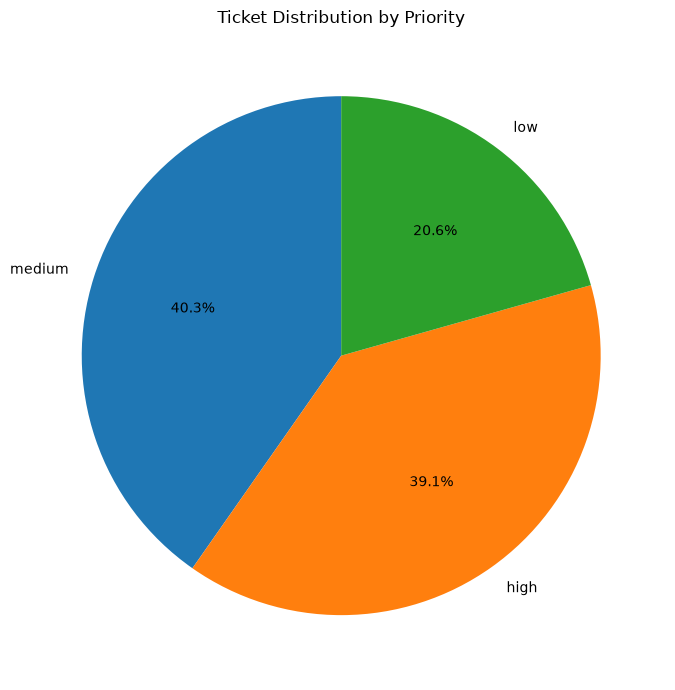

In [17]:
priority_counts = df["priority"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    priority_counts.values,
    labels=priority_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Ticket Distribution by Priority")
plt.tight_layout()
plt.show()

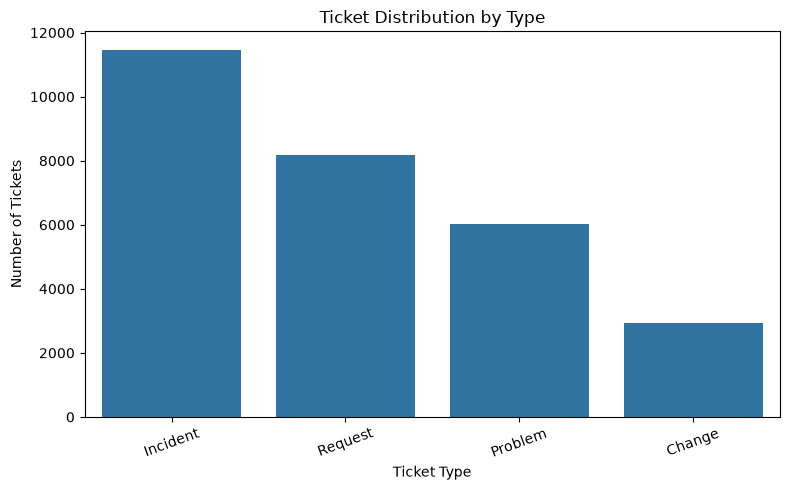

In [18]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.title("Ticket Distribution by Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

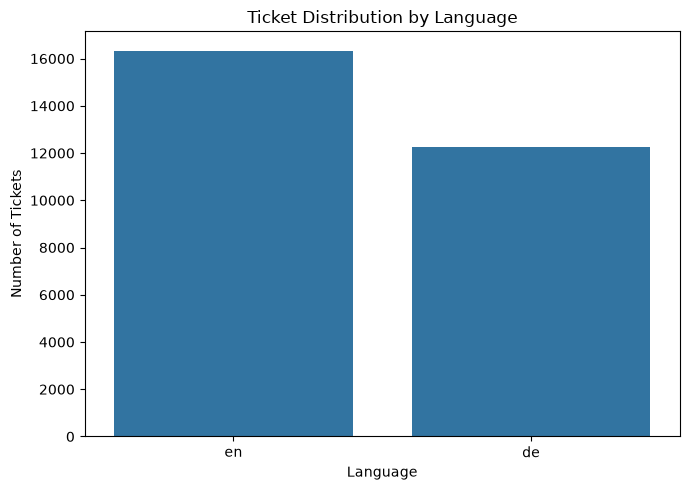

In [19]:
language_counts = df["language"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(
    x=language_counts.index,
    y=language_counts.values
)

plt.xlabel("Language")
plt.ylabel("Number of Tickets")
plt.title("Ticket Distribution by Language")
plt.tight_layout()
plt.show()

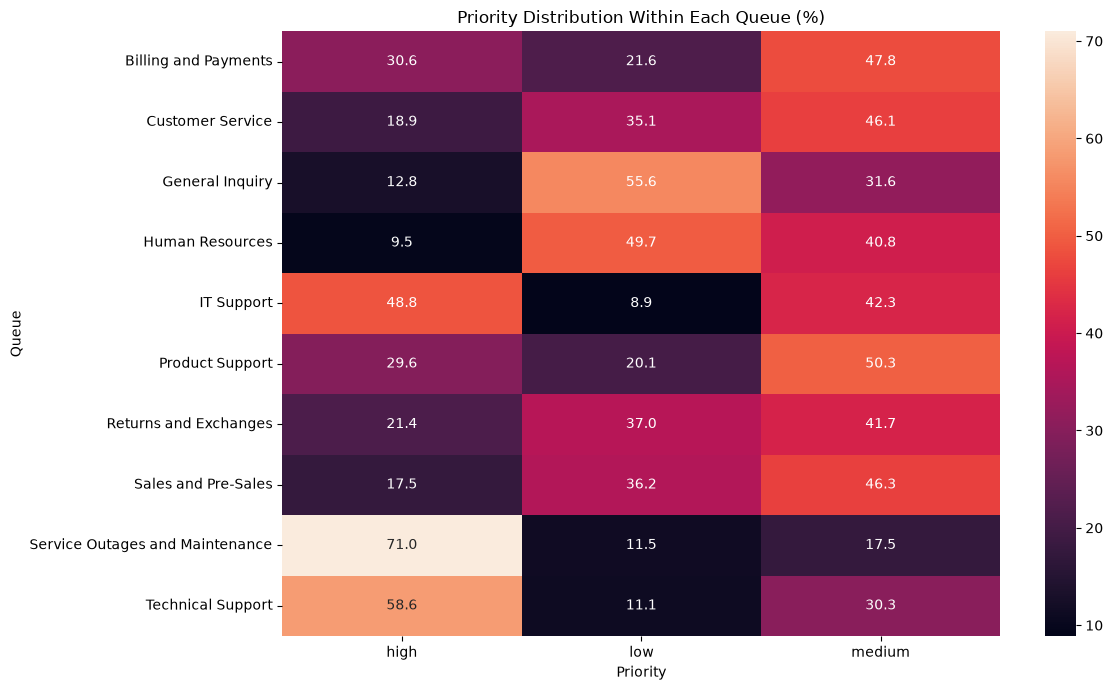

In [20]:
queue_priority = pd.crosstab(
    df["queue"],
    df["priority"],
    normalize="index"
) * 100

plt.figure(figsize=(12, 7))
sns.heatmap(
    queue_priority,
    annot=True,
    fmt=".1f"
)

plt.xlabel("Priority")
plt.ylabel("Queue")
plt.title("Priority Distribution Within Each Queue (%)")
plt.tight_layout()
plt.show()

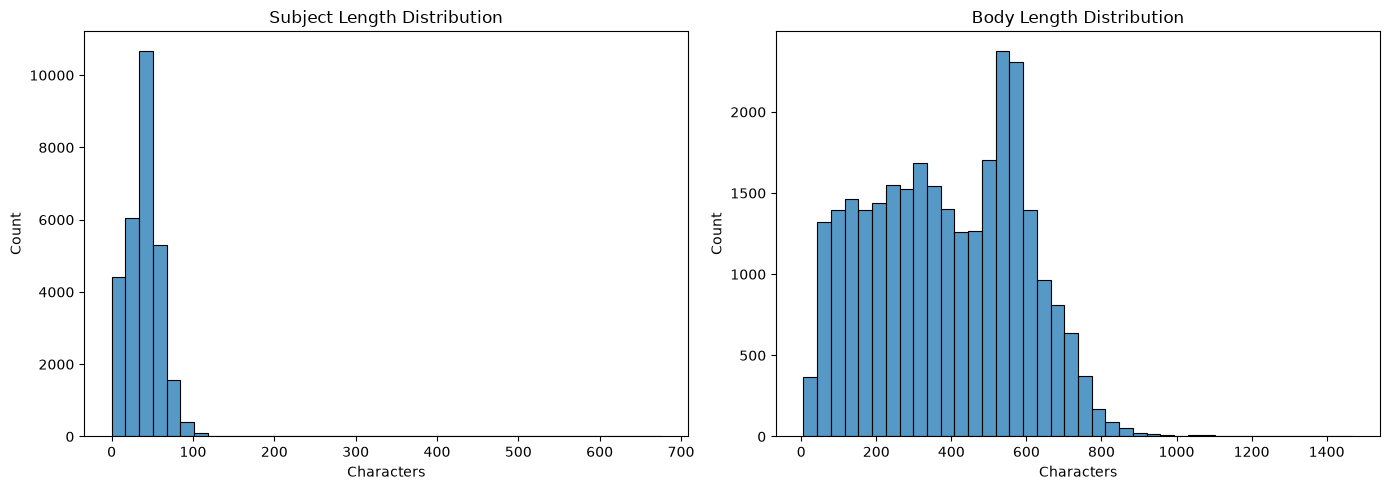

In [21]:
df["subject_length"] = df["subject"].fillna("").str.len()
df["body_length"] = df["body"].fillna("").str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df["subject_length"],
    bins=40,
    ax=axes[0]
)

axes[0].set_title("Subject Length Distribution")
axes[0].set_xlabel("Characters")

sns.histplot(
    df["body_length"],
    bins=40,
    ax=axes[1]
)

axes[1].set_title("Body Length Distribution")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

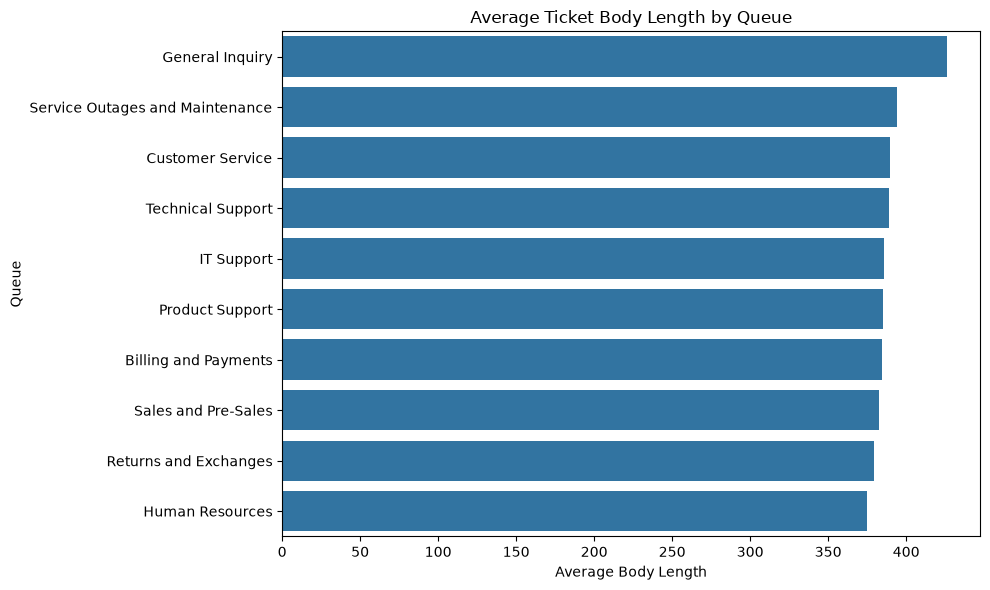

In [22]:
avg_body_length = (
    df.groupby("queue")["body_length"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=avg_body_length.values,
    y=avg_body_length.index
)

plt.xlabel("Average Body Length")
plt.ylabel("Queue")
plt.title("Average Ticket Body Length by Queue")
plt.tight_layout()
plt.show()

In [23]:
queue_priority = pd.crosstab(df["queue"],df["priority"],normalize="index")*100
queue_priority = queue_priority[["low","medium","high"]]
queue_priority

priority,low,medium,high
queue,,,
Billing and Payments,21.592539,47.847920,30.559541
Customer Service,35.074977,46.063730,18.861293
General Inquiry,55.555556,31.604938,12.839506
Human Resources,49.652778,40.798611,9.548611
IT Support,8.884358,42.266239,48.849403
Product Support,20.144707,50.266565,29.588728
Returns and Exchanges,36.951983,41.684064,21.363953
Sales and Pre-Sales,36.165577,46.296296,17.538126
Service Outages and Maintenance,11.498258,17.508711,70.993031


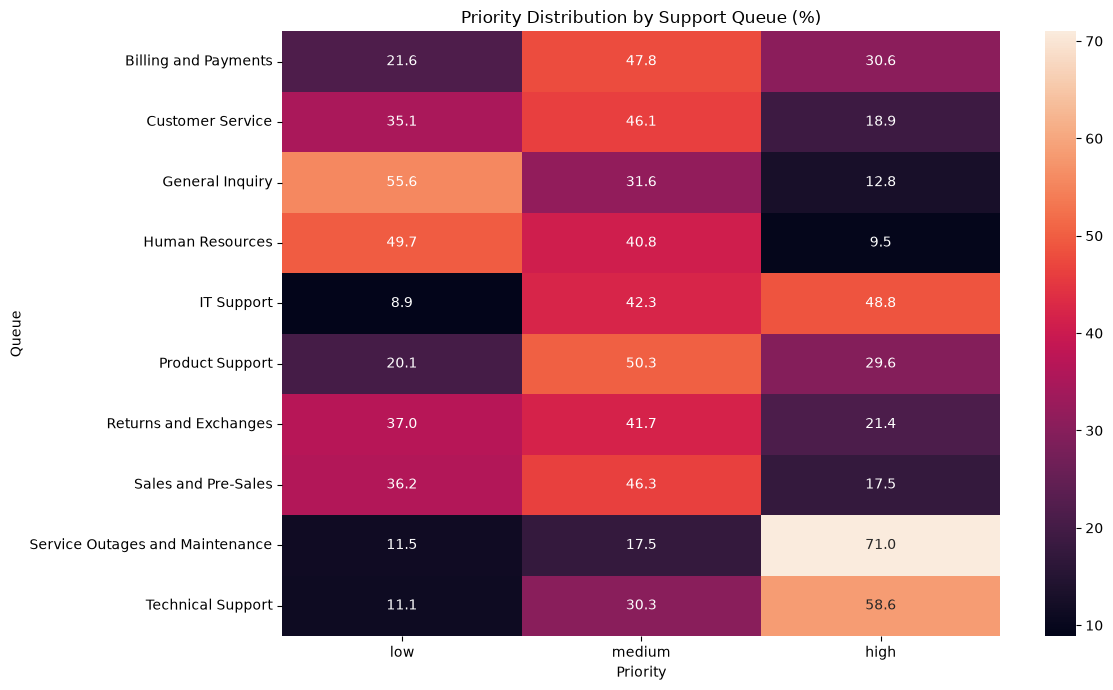

In [24]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    queue_priority,
    annot=True,
    fmt=".1f"
)

plt.xlabel("Priority")
plt.ylabel("Queue")
plt.title("Priority Distribution by Support Queue (%)")
plt.tight_layout()
plt.show()

In [25]:
df["body_length"] = df["body"].fillna("").str.len()

body_length_by_queue = (
    df.groupby("queue")["body_length"]
    .mean()
    .sort_values(ascending=False)
)

body_length_by_queue

queue
General Inquiry                    426.007407
Service Outages and Maintenance    394.412892
Customer Service                   389.911668
Technical Support                  388.864745
IT Support                         385.625109
Product Support                    385.001142
Billing and Payments               384.395624
Sales and Pre-Sales                382.650327
Returns and Exchanges              379.129436
Human Resources                    374.843750
Name: body_length, dtype: float64

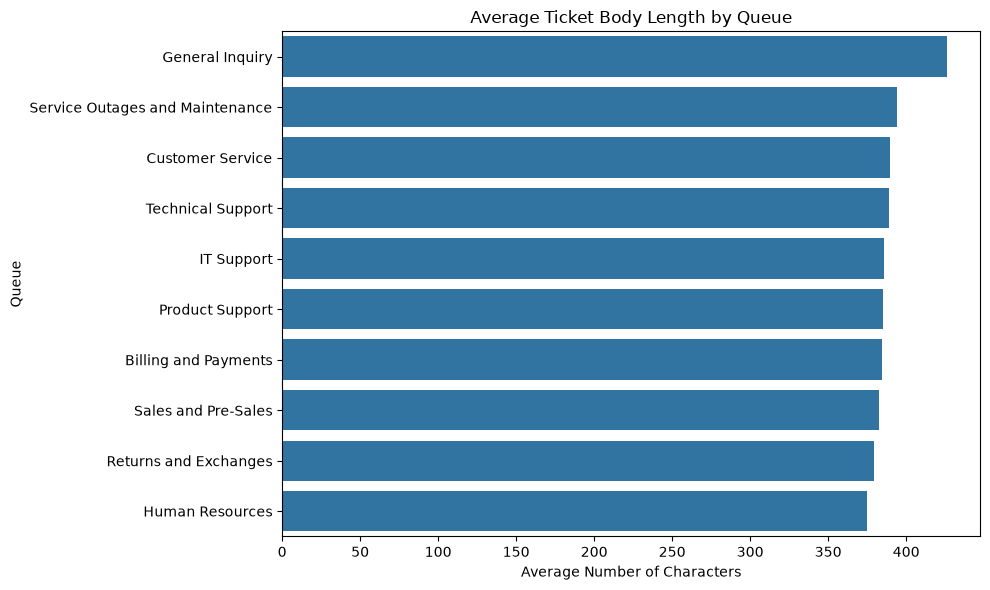

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=body_length_by_queue.values,
    y=body_length_by_queue.index
)

plt.xlabel("Average Number of Characters")
plt.ylabel("Queue")
plt.title("Average Ticket Body Length by Queue")

plt.tight_layout()
plt.show()

In [27]:
from collections import Counter
import re

text = " ".join(
    df["body"]
    .fillna("")
    .astype(str)
    .str.lower()
)

words = re.findall(r"\b[a-zA-Z]{2,}\b", text)

word_counts = Counter(words)

word_counts.most_common(20)

[('the', 51695),
 ('to', 43996),
 ('and', 35876),
 ('die', 20218),
 ('und', 17640),
 ('zu', 16004),
 ('in', 15699),
 ('you', 13085),
 ('data', 12567),
 ('der', 11165),
 ('we', 11081),
 ('this', 10439),
 ('for', 10336),
 ('on', 9949),
 ('would', 9359),
 ('your', 9129),
 ('problem', 9101),
 ('our', 9101),
 ('issue', 8883),
 ('is', 8730)]

In [28]:
english_df = df[df["language"] == "en"].copy()

english_text = " ".join(
    english_df["body"]
    .fillna("")
    .astype(str)
    .str.lower()
)

english_words = re.findall(
    r"\b[a-zA-Z]{2,}\b",
    english_text
)

english_word_counts = Counter(english_words)

english_word_counts.most_common(20)

[('the', 42237),
 ('to', 36810),
 ('and', 29969),
 ('you', 11258),
 ('in', 10409),
 ('data', 10391),
 ('we', 9414),
 ('this', 9172),
 ('on', 8653),
 ('for', 8468),
 ('would', 8287),
 ('our', 7755),
 ('your', 7715),
 ('is', 7406),
 ('issue', 7383),
 ('have', 7232),
 ('be', 7021),
 ('support', 6891),
 ('could', 6769),
 ('of', 6680)]

In [29]:
german_df = df[df["language"] == "de"].copy()

german_text = " ".join(
    german_df["body"]
    .fillna("")
    .astype(str)
    .str.lower()
)

german_words = re.findall(
    r"\b[a-zA-Z]{2,}\b",
    german_text
)

german_word_counts = Counter(german_words)

german_word_counts.most_common(20)

[('die', 20217),
 ('und', 17639),
 ('zu', 16004),
 ('der', 11163),
 ('the', 9458),
 ('ich', 8348),
 ('sie', 8050),
 ('um', 7765),
 ('to', 7186),
 ('das', 7107),
 ('and', 5907),
 ('problem', 5369),
 ('in', 5290),
 ('wir', 5063),
 ('auf', 4888),
 ('eine', 4448),
 ('den', 4082),
 ('bitte', 4072),
 ('es', 3934),
 ('von', 3562)]

In [30]:
queue_distribution = (
    df["queue"]
    .value_counts()
    .to_frame("count")
)

queue_distribution["percentage"] = (
    queue_distribution["count"]
    / len(df)
    * 100
).round(2)

queue_distribution

,count,percentage
queue,,
Technical Support,8362,29.25
Product Support,5252,18.37
Customer Service,4268,14.93
IT Support,3433,12.01
Billing and Payments,2788,9.75
Returns and Exchanges,1437,5.03
Service Outages and Maintenance,1148,4.02
Sales and Pre-Sales,918,3.21
Human Resources,576,2.01


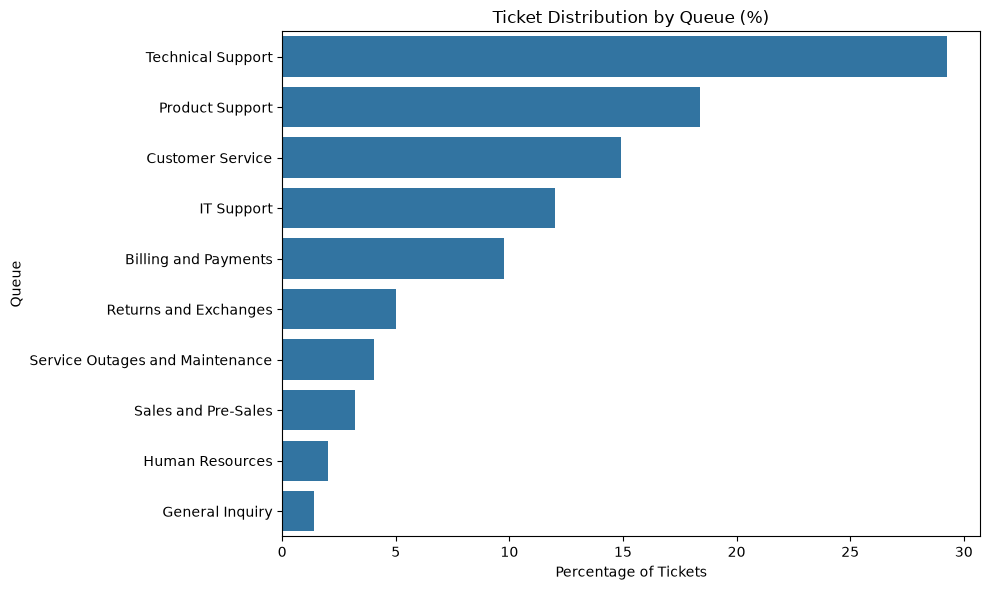

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=queue_distribution.reset_index(),
    x="percentage",
    y="queue"
)

plt.xlabel("Percentage of Tickets")
plt.ylabel("Queue")
plt.title("Ticket Distribution by Queue (%)")
plt.tight_layout()
plt.show()